<a href="https://colab.research.google.com/github/heavyrainseo/deeplearning/blob/main/%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80%EA%B8%B0%EC%B4%88_%EC%84%9C%EB%8C%80%EC%9A%B0%EA%B5%90%EC%88%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 선형회귀 기초

In [ ]:
#@title 한글 쓰기(간단 방법)
!pip install koreanize-matplotlib

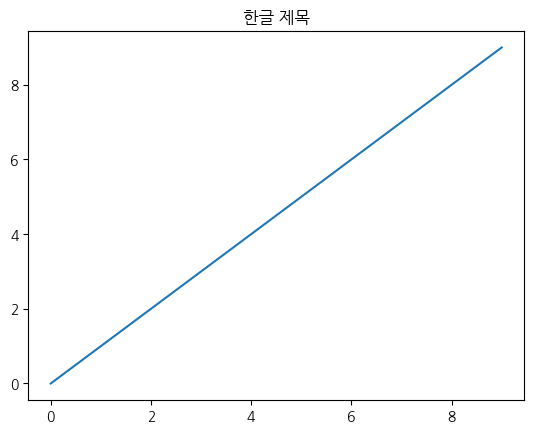

In [2]:
#@title 한글 출력 테스트
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.title("한글 제목")
plt.plot(list(range(10)))
plt.show()

## 선형회귀(Linear Regression) 공식
- **linear**(선형) 출력(활성화:**activation**)  
  - $y=ax+b$

- 오차(**loss**) : **MSE**
  - $error : e = y_i - \hat y_i \quad where \ \hat y_i = ax_i+b$

  - $ MSE(cost) = \frac {1}{n} \sum (y_i - \hat y_i)^2 = \frac {1}{n} \sum (y_i-(ax_i+b))^2 \quad where \ MSE = Mean \ Squared \ Error \ (평균제곱오차) : loss$

- 최적화(optimizer) : 경사하강법(**GD** : Gradient Descent)
  - $\frac {\partial cost}{\partial a} = -\frac {2}{n}\sum x_i (y_i-(ax_i+b))$

  - $\frac {\partial cost}{\partial b} = -\frac {2}{n}\sum (y_i-(ax_i+b))$

- 학습 (학습률로 조절)
  - $a = a - \alpha \cdot \frac {\partial cost}{\partial a} $

  - $b = b - \alpha \cdot \frac {\partial cost}{\partial b} \quad where \ 0 \lt \alpha(learning \ rate) \ < 1$

In [ ]:
#@title MSE 공식 구현
import random
import numpy as np

x = np.array([2,4,6,8])
y = np.array([81,93,91,97])
#print(x,y)

# a, b 초기화
a = random.random()
b = random.random()
print(f'학습 전 a : {a:.4f}, b : {b:.4f}')

# 학습률 지정
lr = 0.0005

# MSE를 저장할 리스트 초기화
mses = []

for i in range(100000) :
  mses.append(sum((y-(a*x+b))**2)/4)
  a = a - lr*(-sum(x*(y-(a*x+b))))/4
  b = b - lr*(-sum((y-(a*x+b))))/4
  #print(mse,a,b)

print(f'학습 종료 후 a:{a:.4f}, b:{b:.4f}, y:{a*x+b}')

학습 전 a : 0.3232, b : 0.1203
학습 종료 후 a:2.3038, b:78.9770, y:[83.58473577 88.19243029 92.80012481 97.40781933]


8.300087877960129


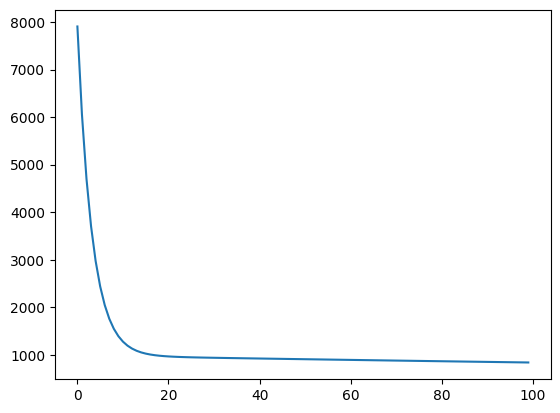

In [ ]:
#@title 오차 확인
# 1000개의 mse를 10개 단위로 확대해서 그려 본다.
import matplotlib.pyplot as plt
print(mses[-1])
plt.plot(mses[:1000:10])
plt.show()

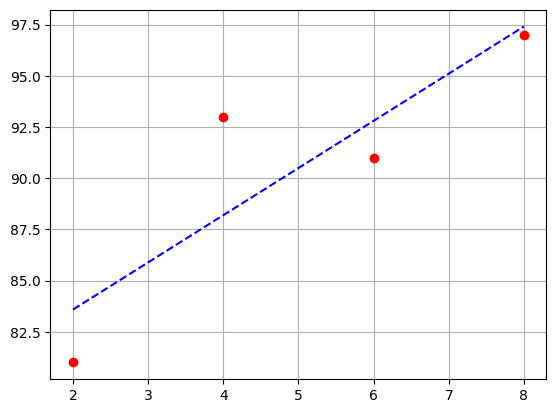

In [ ]:
#@title 결과와 예측선 그래프
plt.plot(x,y,'ro')
plt.plot(x,a*x+b,'b--')
plt.grid()
plt.show()

##  Simple Linear Regression with tensorfow
- Sequential model, Dense layer
- optimizer : sgd, loss : mse, activation : linear

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

In [ ]:
x = np.array([2,4,6,8])
y = np.array([81,93,91,97])

In [ ]:
# 모델 생성
model = Sequential()
# shape=(1,) : 튜플로 만들기
model.add(Input(shape=(1,)))
#model.add(Dense(1, input_dim=1))
model.add(Dense(1))
# 최적화, loss 함수 지정
model.compile(optimizer='sgd', loss='mse')
# 초기 가중치(a, b) 출력
model.get_weights()

[array([[1.2606908]], dtype=float32), array([0.], dtype=float32)]

In [ ]:
%%time
# 학습 실행
hist = model.fit(x,y,epochs=1000,verbose=0)
model.get_weights()

CPU times: user 32.2 s, sys: 10 s, total: 42.2 s
Wall time: 43.4 s


[array([[2.7991548]], dtype=float32), array([76.021255], dtype=float32)]

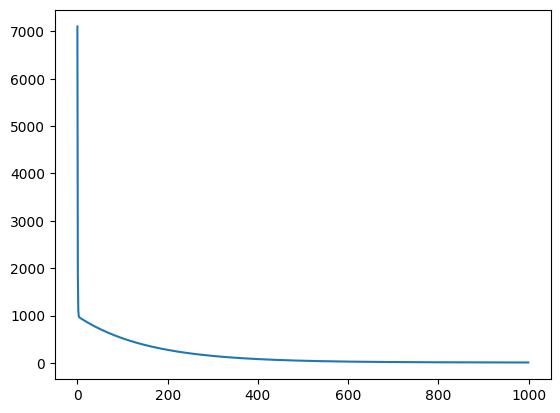

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])

In [ ]:
test_x = np.array(list(range(9)))
pd.Series(model.predict(test_x).flatten())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


,0
0,76.022476
1,78.821426
2,81.620377
3,84.419327
4,87.218277
5,90.017227
6,92.816177
7,95.615135
8,98.414085


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


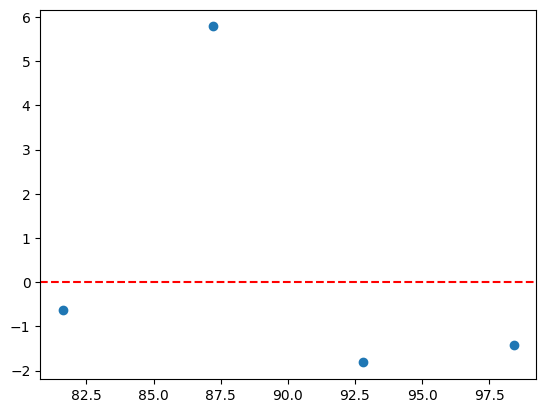

In [ ]:
#@title 잔차(residual) 차트
import matplotlib.pyplot as plt
import pandas as pd

result = pd.DataFrame({'y':y, 'predict':model.predict(x).flatten()})
plt.scatter(result.predict, result.y - result.predict)
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [ ]:
hist.history['loss'][-1]

9.788688659667969

##  tensorflow - hidden layer
- hidden layer activation : relu

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
import numpy as np
x = np.array([2,4,6,8])
y = np.array([81,93,91,97])

In [ ]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(8,activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

In [ ]:
%%time
hist = model.fit(x,y,epochs=10000,verbose=0)

CPU times: user 5min 20s, sys: 1min 39s, total: 7min
Wall time: 7min 6s


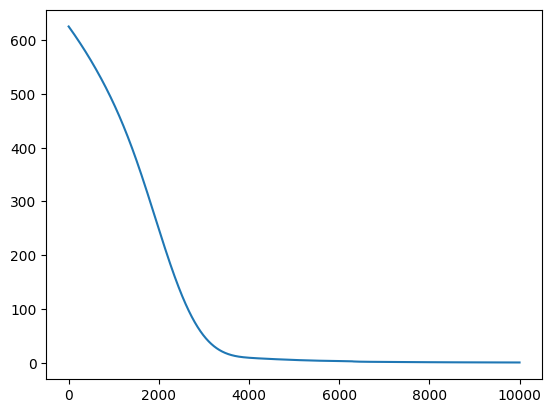

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])

In [ ]:
model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[81.24359 ],
       [92.21361 ],
       [92.01343 ],
       [96.563736]], dtype=float32)

In [ ]:
model.get_weights()

[array([[ 1.3620559 ,  0.9957784 ,  0.83175576,  1.3017799 , -0.09915721,
         -0.27381396, -0.86402816,  0.02510915]], dtype=float32),
 array([-5.4479046 ,  4.626978  ,  4.827977  ,  4.290521  ,  0.        ,
         5.163755  ,  5.182275  , -0.21602438], dtype=float32),
 array([[-4.102881  ],
        [ 2.774905  ],
        [ 2.9559953 ],
        [ 2.6192017 ],
        [-0.07354265],
        [ 2.804714  ],
        [ 2.7520545 ],
        [-0.05881741]], dtype=float32),
 array([3.178881], dtype=float32)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


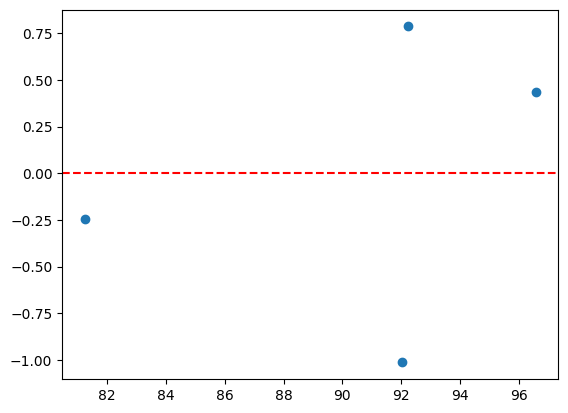

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

result = pd.DataFrame({'y':y, 'predict':model.predict(x).flatten()})
plt.scatter(result.predict, result.y - result.predict)
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [ ]:
model.save("lr_hidden.keras")

## 단순 선형회귀 연습 - flights
- 미국 월별/연도별 비행기 탑승객 기록
- 월 단위 합계 및 연도에 대한 탑승객 예측

### 데이터 로딩 및 가공

In [ ]:
#@title 데이터 로딩
import seaborn as sns

flights = sns.load_dataset('flights')
flights.head(12)

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
5,1949,Jun,135
6,1949,Jul,148
7,1949,Aug,148
8,1949,Sep,136
9,1949,Oct,119


In [ ]:
#@title Correlation Ratio(상관비)

float(eta(flights.month, flights.passengers))

0.32574766895343765

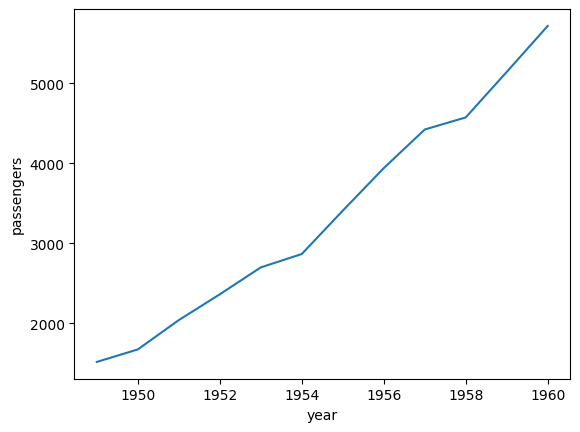

In [ ]:
#@title 연도별 승객 수 증가 추이 그래프
import matplotlib.pyplot as plt

flt_year = flights.groupby("year", as_index=False)["passengers"].sum()
sns.lineplot(data=flt_year, x="year", y="passengers")
plt.show()

<Axes: xlabel='year', ylabel='month'>

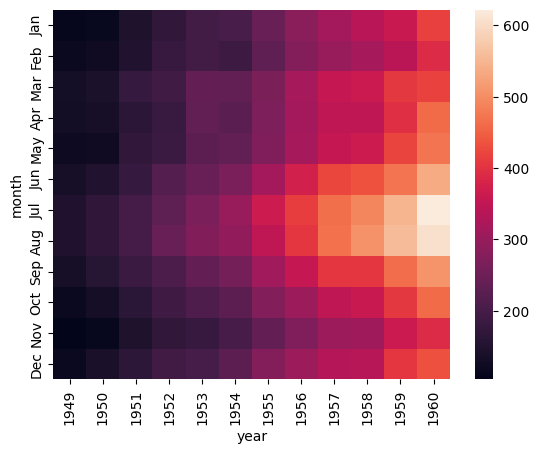

In [ ]:
#@title 분석을 위한 히트맵
#df = flights.replace({'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6, 'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12})

df_pivot = flights.pivot(index='month', columns='year', values='passengers')
sns.heatmap(df_pivot)

In [ ]:
#@title 데이터 분리 및 표준화
# 표준화를 하지 않으면 입력값이 커서 발산한다.
def std_year(y) :
  return (y.astype('float32') - y.mean()) / y.std()

std_year(flt_year.year)[:5]

,year
0,-1.525426
1,-1.248075
2,-0.970725
3,-0.693375
4,-0.416025


### 일반적인 학습 방법

In [ ]:
#@title model 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='sgd', loss='mse')
print('초기값 : ', model.get_weights())

초기값 :  [array([[1.1754421]], dtype=float32), array([0.], dtype=float32)]


In [ ]:
#@title 학습
%%time
hist = model.fit(std_year(flt_year.year), flt_year.passengers, epochs=5000, verbose=0)

#@title 모델 저장
model.save('ml_flights.keras')

model.get_weights()

CPU times: user 2min 42s, sys: 48.6 s, total: 3min 30s
Wall time: 3min 33s


[array([[1381.238]], dtype=float32), array([3363.5774], dtype=float32)]

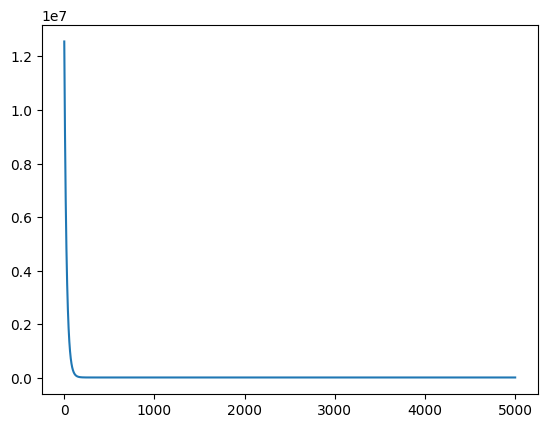

In [ ]:
#@title loss 차트 생성
import matplotlib.pyplot as plt

plt.plot(hist.history['loss'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


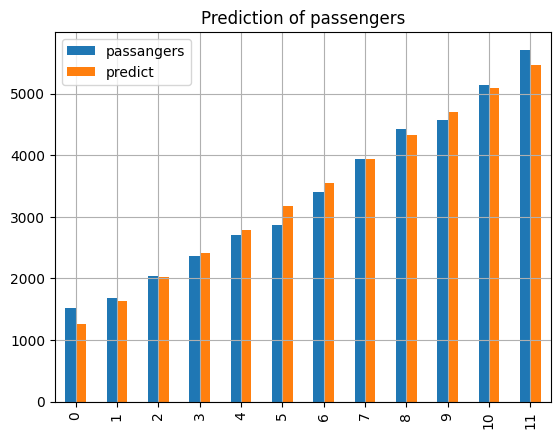

In [ ]:
#@title 예측 실행 및 결과 출력
pred = model.predict(norm_year(flt_year.year))

import pandas as pd
import numpy as np

res = pd.DataFrame({'passengers':flt_year.passengers, 'predict':pred.flatten()})

res.plot.bar(title='Prediction of passengers')
plt.grid()

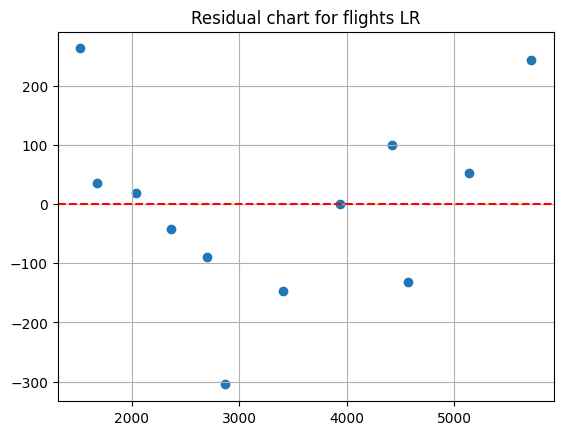

In [ ]:
#@title 잔차 그래프 (Regidual chart)
# x축 : pred(x), y축 : 잔차(y - pred(x))

plt.title('Residual chart for flights LR')
plt.grid()
plt.scatter(res['passengers'], res['passengers']-res['predict'])
plt.axhline(0, color='red', linestyle='--')

## 잔차 분포에 따른 해결 방법

**상황별 조치 가이드**

1. "무질서하게 퍼져있는 점들" (Random Cloud)  
모양: 어떤 규칙적임 없이 위아래로 무작위하게 흐트라퍼져있는 모양. (마치 구름이나 안개 같은 모양)  
원인: 아무 문제도 없는 상태  
조치: 지금 그대로가 좋음.

1. "U자 혹은 곡선 모양" (Curved Shape)  
모양: 점들이 무작위로 퍼져있는 게 아니라, 어떤 곡선을 그리듯이 줄을 서 있는 형태 (예: 아래로 처졌다가 다시 위로 올라가는 U자 모양)  
원인: 데이터가 직선이 아니라 곡선으로 변하는 비선형성(Non-linearity)인데 모델이 직선으로만 예측하려 해서 생기는 오류  
조치: log1p 시도 (아주 심하게 곡선이면 Polynomial Regression 같은 다른 방식을 써야 함)   

1. "나팔/부채 모양" (Fan Shape)  
모양: 가로축(Year)이 커질수록, 점들이 위아래로 점점 더 넓게 퍼져나가는 형태.  
원인: 이분산성(Heteroscedasticity, 데이터 값이 커질수록 오차도 같이 커지는 현상)  
조치: log1p 적용(로그 변환은 큰 값들을 압축시켜서 퍼짐 정도를 일정하게 맞춰주는 역할)  

- 학습 입력값 변환 : np.log1p(passengers)
- 예측 출력값 변환 : np.expm1(predict_value)

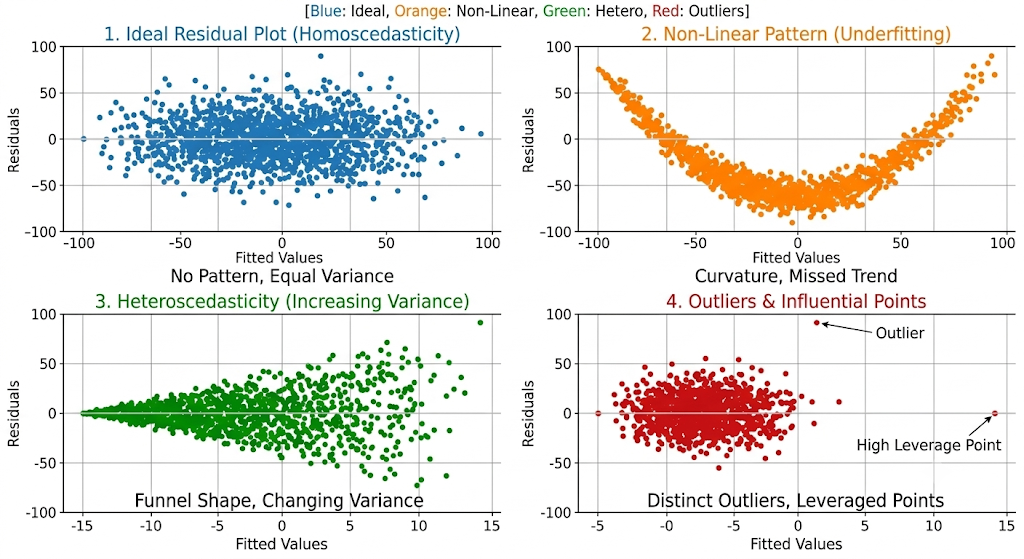

|패턴 번호 / 유형|	원인 분석|	해결 방법|
|-|-|-|
|1. 이상적인 잔차</br> (Ideal)	|잔차가 0을 중심으로 특정 패턴 없이 무작위 분포</br> (선형회귀 기본 가정 충족)	|현재 모델 유지 (별도 조치 필요 없음)|
|2. 비선형 패턴 </br>(Non-Linear)	|독립변수와 종속변수 간의 비선형(곡선) 관계를 모델이 반영하지 못함	|• 다항 회귀(Polynomial Regression) 적용 (x2 ,x3 등 추가) </br> • 비선형 모델(결정 트리, Random Forest, XGBoost 등)로 교체|
|3. 이산성 / 등분산성 위반 </br>(Heteroscedasticity)	|예측값이 증가함에 따라 오차의 변동폭(분산)이 점점 커지거나 작아짐|	• 종속변수 y에 로그 변환(log1p) 또는 Box-Cox 변환 적용 </br> • 가중 최소제곱법(WLS, Weighted Least Squares) 사용|
|4. 이상치 및 고영향점</br> (Outliers & High Leverage)|	회귀 직선을 강하게 왜곡하는 극단적인 이상치가 존재함|• 이상치 데이터의 원인 확인 후 제거 또는 대치(Imputation)  </br>• 이상치 영향에 강한 로버스트 회귀(Robust Regression, RANSAC, Huber) 적용|

In [ ]:
#@title model 생성 (동일한 모델)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='sgd', loss='mse')
print('초기값 : ', model.get_weights())

초기값 :  [array([[0.3325218]], dtype=float32), array([0.], dtype=float32)]


In [ ]:
#@title 학습
%%time

import numpy as np

hist = model.fit(flt_year.year-flt_year.year.min(),
       np.log(flt_year.passengers),
       epochs=5000, verbose=0)

model.get_weights()

CPU times: user 2min 38s, sys: 48.4 s, total: 3min 27s
Wall time: 3min 31s


[array([[0.1214287]], dtype=float32), array([7.368181], dtype=float32)]

In [ ]:
#@title 모델 저장
model.save('ml_log_flights.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


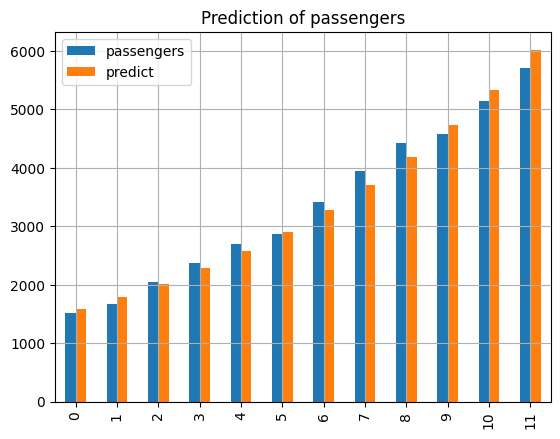

In [ ]:
#@title 예측 실행 및 결과 출력
pred = np.exp(model.predict(flt_year.year-flt_year.year.min()))

import pandas as pd
import numpy as np

res = pd.DataFrame({'passengers':flt_year.passengers, 'predict':np.reshape(pred, -1)})

res.plot.bar(title='Prediction of passengers')
plt.grid()

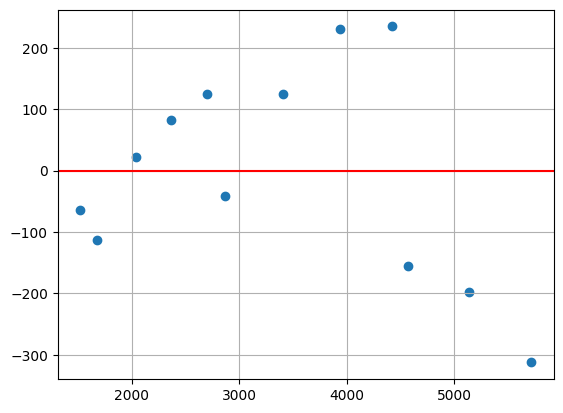

In [ ]:
#@title 잔차 그래프 (Regidual chart)

plt.grid()
plt.scatter(res['passengers'],
    res['passengers']-res['predict'])
plt.axhline(0, color='red')
plt.show()

## 다중 선형회귀 연습 - tips
- 여러 개의 독립변수 중 유의미한 상관 관계가 있는 독립 변수를 취한다.
  - 상관계수 $ r = \frac {Cov(x,y)}{\sigma x \cdot \sigma y} \ , \ -1 \le r \le 1 $
  - Correlation Ratio(상관비) : $\eta = \sqrt {\frac {SS_{between}}{SS_{total}}} ,\ 0 \le \eta \le 1$
    - $SS_{between} = \sum n_k(\bar {y_k} - \bar y)^2$
    - $SS_{total}=\sum (y_i - \bar y)^2$
  - 엑셀 : correl(), pandas : corr()
  - seaborn : sns.heatmap(x, annot=True)
  - 데이터의 이상치 분포 확인 - 상자수염그림 : sns.boxplot(x)

In [ ]:
import pandas as pd

# 상관비 구하기
def eta(categories, values):
    df = pd.DataFrame({'cat': categories, 'val': values})
    group_means = df.groupby('cat', observed=True)['val'].mean()
    overall_mean = df['val'].mean()
    n_per_group = df.groupby('cat', observed=True)['val'].count()

    ss_between = ((group_means - overall_mean) ** 2 * n_per_group).sum()
    ss_total = ((df['val'] - overall_mean) ** 2).sum()

    return (ss_between / ss_total) ** 0.5

In [ ]:
#@title 데이터 로딩
import seaborn as sns
tips = sns.load_dataset('tips')
print(tips.day.unique())
tips.head()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


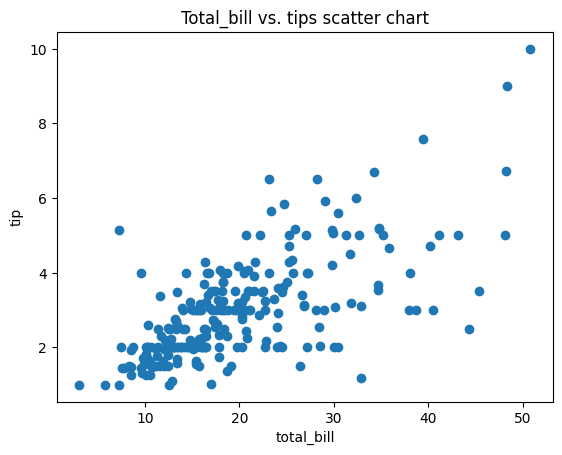

In [ ]:
import matplotlib.pyplot as plt

plt.title('Total_bill vs. tips scatter chart')
plt.scatter(tips.total_bill, tips.tip)
plt.xlabel('total_bill')
plt.ylabel('tip')
plt.show()

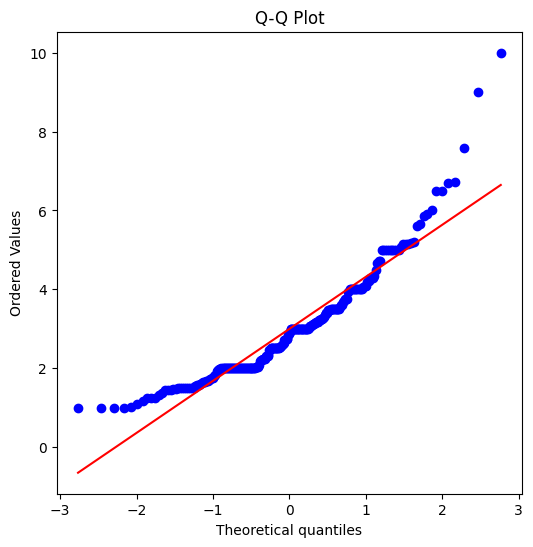

In [ ]:
#@title Q-Q Plot (Quantile-Quantile Plot)
'''해석: 데이터 포인트들이 빨간색 대각선 위에 정확히 일치할수록
정규분포에 가깝다.
팁 데이터의 경우, 양쪽 끝(특히 오른쪽 끝)에서 빨간 선을
크게 벗어나는 형태가 나타나므로 이는 데이터가 정규분포가 아니라는
강한 증거.'''
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(tips['tip'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [ ]:
# 통계적 검정 (Shapiro-Wilk Test)
from scipy.stats import shapiro

stat, p = shapiro(tips['tip'])
print(f"Statistics={stat:.3f}, p-value={p:.3f}")

if p > 0.05:
    print("정규분포를 따름 (귀무가설 기각 실패)")
else:
    print("정규분포를 따르지 않음 (귀무가설 기각)")

Statistics=0.898, p-value=0.000
정규분포를 따르지 않음 (귀무가설 기각)


In [ ]:
for i in ['sex','smoker','day','time'] :
  print({i},':',eta(tips[i], tips.tip))

{'sex'} : 0.08886206109073627
{'smoker'} : 0.005928539527806694
{'day'} : 0.14309574577588202
{'time'} : 0.12162906226028686


<Axes: >

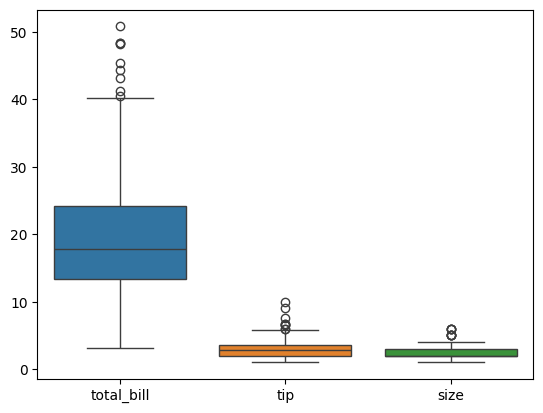

In [ ]:
#@title 이상치 확인
sns.boxplot(tips)

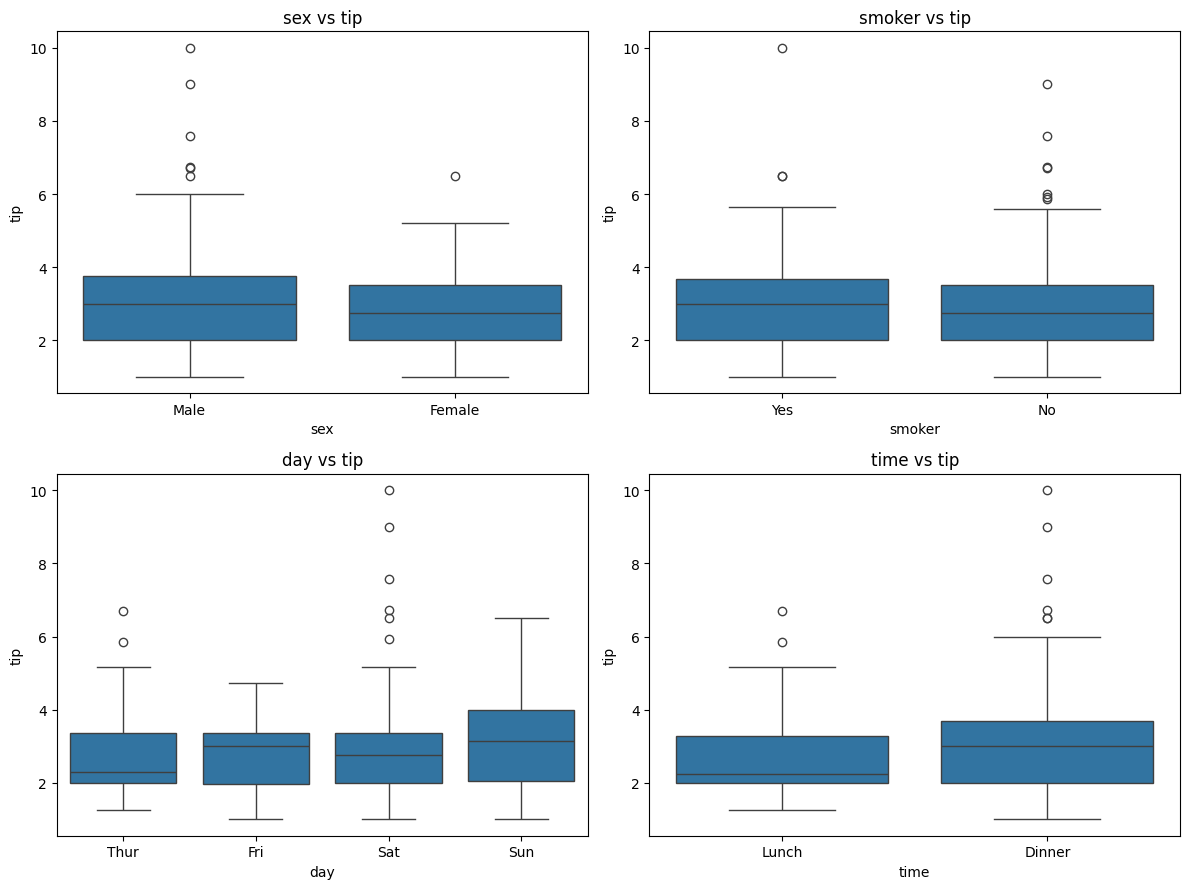

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

cats = ['sex', 'smoker', 'day', 'time']
for i, col in enumerate(cats):
    sns.boxplot(x=col, y='tip', data=tips, ax=axes[i])
    axes[i].set_title(f"{col} vs tip")

plt.tight_layout()
plt.show()

In [ ]:
#@title 데이터 정제
tips.replace({'Male':1, 'Female':2}, inplace=True)
tips.day = tips.day.cat.codes
tips.time = tips.time.cat.codes #replace({'Lunch':1, 'Dinner':2}, inplace=True)
tips.replace({'No':1, 'Yes':2}, inplace=True)
tips.head()

/tmp/ipykernel_1619/2535989097.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tips.replace({'Male':1, 'Female':2}, inplace=True)
/tmp/ipykernel_1619/2535989097.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  tips.replace({'Male':1, 'Female':2}, inplace=True)
/tmp/ipykernel_1619/2535989097.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,2,1,3,1,2
1,10.34,1.66,1,1,3,1,3
2,21.01,3.50,1,1,3,1,3
3,23.68,3.31,1,1,3,1,2
4,24.59,3.61,2,1,3,1,4


<Axes: >

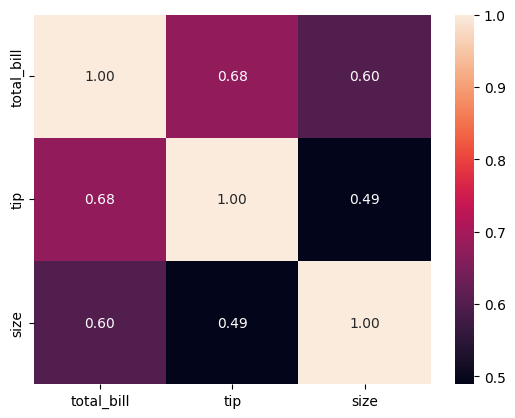

In [ ]:
#@title 상관계수 r 확인
sns.heatmap(tips.corr(numeric_only=True),annot=True, fmt='.2f')

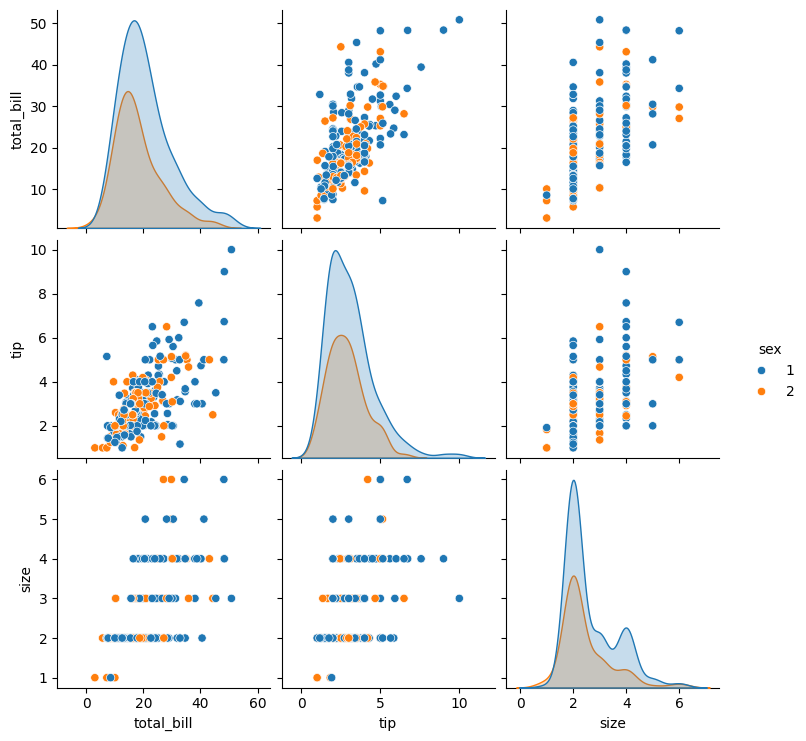

In [ ]:
sns.pairplot(tips, hue='sex')

In [ ]:
#@title 학습/결과 데이터 분리
x = tips.iloc[:,[0,6]]
y = tips['tip']

In [ ]:
#@title 선형회귀 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(16,activation='relu'))
model.add(Dense(1))
model.compile(loss='mse', optimizer='adam')
model.get_weights()

[array([[-0.01371759, -0.5152223 , -0.2534676 , -0.31959665, -0.5431591 ,
          0.2672153 , -0.2462742 , -0.3929096 , -0.5769658 ,  0.13710636,
          0.35425687,  0.21286494,  0.05630505,  0.01964223, -0.0377292 ,
         -0.53497344],
        [-0.5066148 ,  0.01606798,  0.14822125,  0.19771397, -0.2130045 ,
         -0.49167886, -0.31880116, -0.42100897,  0.12871969,  0.28689557,
         -0.31250322, -0.3260036 ,  0.54636884,  0.4356848 , -0.42255753,
          0.30849397]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 array([[-0.58791494],
        [ 0.5139935 ],
        [ 0.14583474],
        [-0.22979519],
        [-0.35097834],
        [ 0.4469794 ],
        [-0.25533745],
        [-0.171581  ],
        [ 0.5314487 ],
        [ 0.30812305],
        [ 0.22541875],
        [-0.02733207],
        [ 0.07771981],
        [ 0.28888118],
        [ 0.08499467],
        [-0.4033933 ]], dtype=float32),
 array([0.],

In [ ]:
#@title 학습 시행
%%time
hist = model.fit(x,y,epochs=1000,verbose=0)
model.get_weights()

CPU times: user 54 s, sys: 11.5 s, total: 1min 5s
Wall time: 1min 4s


[array([[-0.01371759, -0.5152223 , -0.2534676 , -0.31959665, -0.5431591 ,
          0.20640609, -0.2462742 , -0.3929096 , -0.5769658 ,  0.07431743,
          0.29127955,  0.28200287, -0.0145642 , -0.03063728, -0.0377292 ,
         -0.53497344],
        [-0.5066148 ,  0.01606798,  0.14822125,  0.19771397, -0.2130045 ,
         -0.44266397, -0.31880116, -0.42100897,  0.12871969,  0.3388847 ,
         -0.27407327, -0.46787107,  0.60420394,  0.50931877, -0.42255753,
          0.30849397]], dtype=float32),
 array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.24742204,  0.        ,  0.        ,  0.        ,  0.26305112,
         0.22485001, -0.44840854,  0.3133384 ,  0.31707078,  0.        ,
         0.        ], dtype=float32),
 array([[-0.58791494],
        [ 0.5139935 ],
        [ 0.14583474],
        [-0.22979519],
        [-0.35097834],
        [ 0.3578195 ],
        [-0.25533745],
        [-0.171581  ],
        [ 0.5314487 ],
        [ 0.2772487 ],
      

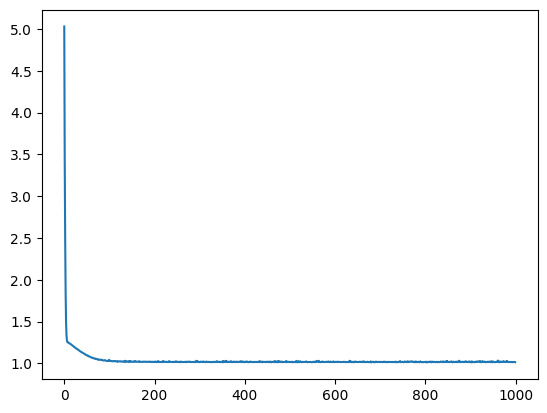

In [ ]:
#@title loss 차트
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


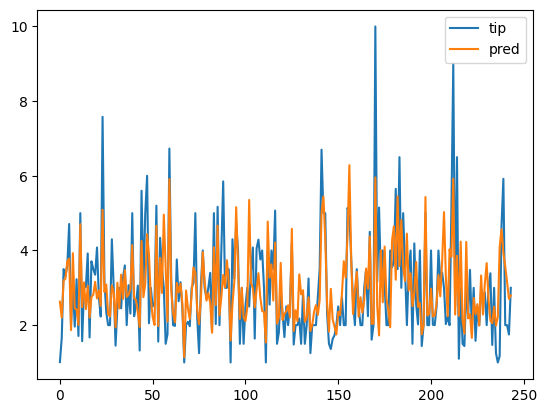

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


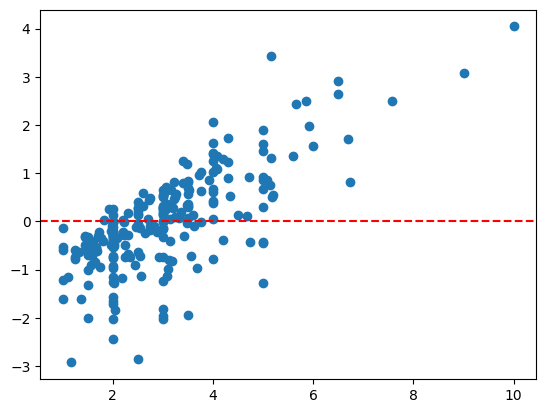

In [ ]:
#@title 학습 데이터와 예측 결과 비교
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({'tip':tips['tip'],'pred':np.reshape(model.predict(x), -1)})
df.plot()
plt.show()

result = pd.DataFrame({'tip':tips.tip, 'pred':model.predict(x).flatten()})
plt.scatter(result.tip, result.tip - result.pred)
plt.axhline(0, color='red', linestyle='--')
plt.show()

In [ ]:
tips.iloc[df[df.tip>6].index,:]

,total_bill,tip,sex,smoker,day,time,size
23,39.42,7.58,1,1,2,1,4
59,48.27,6.73,1,1,2,1,4
141,34.30,6.70,1,1,0,0,6
170,50.81,10.00,1,2,2,1,3
183,23.17,6.50,1,2,3,1,4
212,48.33,9.00,1,1,2,1,4
214,28.17,6.50,2,2,2,1,3


### tips 개선 모델
- log1p, expm1 함수 적용

In [ ]:
tipsmodel = Sequential()
tipsmodel.add(Input(shape=(2,)))
tipsmodel.add(Dense(16,activation='relu'))
tipsmodel.add(Dense(1))
tipsmodel.compile(loss='mse', optimizer='adam')
tipsmodel.get_weights()

[array([[-0.03241944,  0.23377699,  0.242684  ,  0.50309   , -0.4405261 ,
         -0.4860941 ,  0.13831985, -0.08827174,  0.45047736, -0.17913094,
         -0.10353807, -0.3023567 ,  0.16134351,  0.2535839 , -0.12349981,
         -0.28877932],
        [ 0.11238587,  0.55309   ,  0.38343298, -0.3116648 , -0.21359915,
         -0.24897397, -0.06134403, -0.55088174,  0.14745069, -0.19588059,
          0.3676985 ,  0.19332796,  0.17753434,  0.48488963, -0.08437857,
         -0.31059343]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       dtype=float32),
 array([[-0.44054535],
        [-0.1405552 ],
        [-0.11759552],
        [ 0.14436185],
        [ 0.3479904 ],
        [ 0.10744506],
        [ 0.02303308],
        [-0.54126257],
        [-0.05889183],
        [-0.5516197 ],
        [ 0.37908715],
        [ 0.42823756],
        [ 0.48566914],
        [-0.18769145],
        [-0.16789562],
        [ 0.15394884]], dtype=float32),
 array([0.],

In [ ]:
def stdize(x):
  return (x-x.mean())/x.std()

In [ ]:
%%time
import numpy as np

history = tipsmodel.fit(np.log1p(x), np.log1p(y), epochs=5000, batch_size=64, verbose=0)
tipsmodel.get_weights()

CPU times: user 3min 19s, sys: 51.4 s, total: 4min 10s
Wall time: 4min 9s


[array([[-0.05330718,  0.1071154 ,  0.08465223,  0.6521574 , -0.4405261 ,
         -0.4860941 ,  0.34042394, -0.08827174,  0.4260422 , -0.17913094,
          0.02986326, -0.3023567 ,  0.29490212,  0.13118257, -0.12349981,
         -0.28877932],
        [ 0.09080552,  0.46720514,  0.25437826, -0.26330784, -0.21359915,
         -0.24897397, -0.00980258, -0.55088174,  0.05035713, -0.19588059,
          0.42106435,  0.19332796,  0.23012084,  0.41256657, -0.08437857,
         -0.31059343]], dtype=float32),
 array([-0.02083841, -0.01988406, -0.08310484, -0.12452742,  0.        ,
         0.        , -0.21183057,  0.        , -0.2191767 ,  0.        ,
        -0.08216555,  0.        , -0.0846694 ,  0.00989356,  0.        ,
         0.        ], dtype=float32),
 array([[-0.423379  ],
        [-0.04812698],
        [-0.01395789],
        [ 0.3000251 ],
        [ 0.3479904 ],
        [ 0.10744506],
        [ 0.19661127],
        [-0.54126257],
        [ 0.06242975],
        [-0.5516197 ],
      

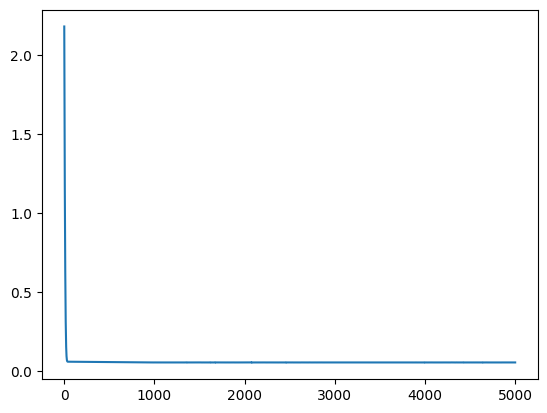

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


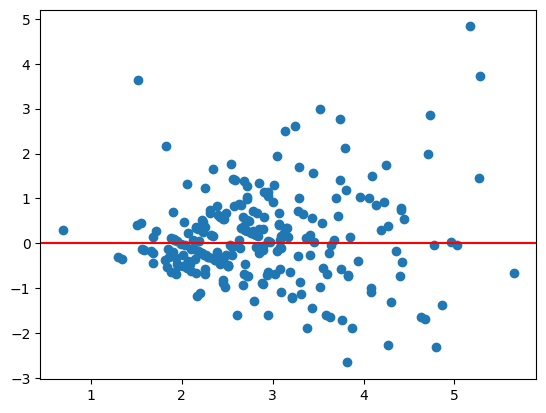

In [ ]:
import pandas as pd
pred = tipsmodel.predict(np.log1p(x)).flatten()

result = pd.DataFrame({'tip':y, 'pred':np.expm1(pred)})
plt.scatter(result.pred, result.tip - result.pred)
plt.axhline(0, color='red')

In [ ]:
result.head(10)

,tip,pred
0,1.01,2.644930
1,1.66,2.087128
2,3.50,3.216272
3,3.31,3.228943
4,3.61,3.707722
5,4.71,3.767820
6,2.00,1.735680
7,3.12,3.901250
8,1.96,2.453574
9,3.23,2.427147


## 다중선형회귀 - Diamonds
- 중요한 독립 변수 : carat, clarity, color
- 종속 변수 : price
- null 값의 개수 확인 : dm.isnull().sum(axis=1)
- 범주형 변수의 치환 : dm.color.map({'E':0, 'I':1, ...)
- 범주형 변수의 one-hot encoding : pd.get_dummies()


### 데이터 로딩 및 정제

In [ ]:
#@title 데이터 로딩
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dm = sns.load_dataset('diamonds')
dm.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
#@title 데이터 확인
# 결측치 확인
print(dm.isnull().sum())

# 데이터 통계치 확인
dm.describe()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
#@title 범주형 변수 확인
print(dm.cut.unique())
print(dm.clarity.unique())
print(dm.color.unique())

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']


In [ ]:
#@title 범주형 -> 정수형 치환
dm1 = dm.copy()

dm1['cut'] = dm1['cut'].cat.codes
dm1['color'] = dm1['color'].cat.codes
dm1['clarity'] = dm1['clarity'].cat.codes

dm1.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,0,1,6,61.5,55.0,326,3.95,3.98,2.43
1,0.21,1,1,5,59.8,61.0,326,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,327,4.05,4.07,2.31
3,0.29,1,5,4,62.4,58.0,334,4.20,4.23,2.63
4,0.31,3,6,6,63.3,58.0,335,4.34,4.35,2.75


<Axes: >

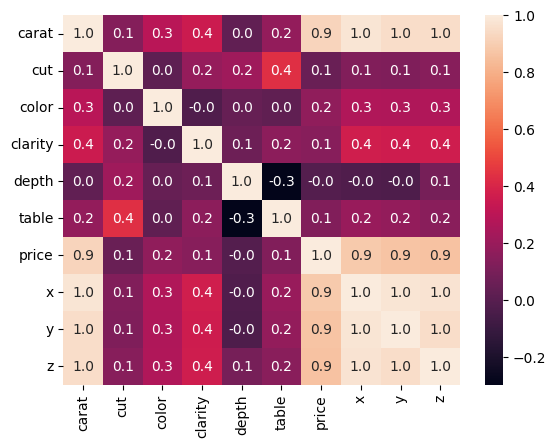

In [ ]:
#@title corr heatmap
sns.heatmap(dm1.corr(), annot=True, fmt='.1f')

In [ ]:
#@title 독립변수와 종속변수 할당
X = dm1[['carat','cut','color','clarity']]
Y = np.log1p(dm1['price'])
X, Y

(       carat  cut  color  clarity
 0       0.23    0      1        6
 1       0.21    1      1        5
 2       0.23    3      1        3
 3       0.29    1      5        4
 4       0.31    3      6        6
 ...      ...  ...    ...      ...
 53935   0.72    0      0        5
 53936   0.72    3      0        5
 53937   0.70    2      0        5
 53938   0.86    1      4        6
 53939   0.75    0      0        6
 
 [53940 rows x 4 columns],
 0        5.789960
 1        5.789960
 2        5.793014
 3        5.814131
 4        5.817111
            ...   
 53935    7.922261
 53936    7.922261
 53937    7.922261
 53938    7.922261
 53939    7.922261
 Name: price, Length: 53940, dtype: float64)

<Axes: >

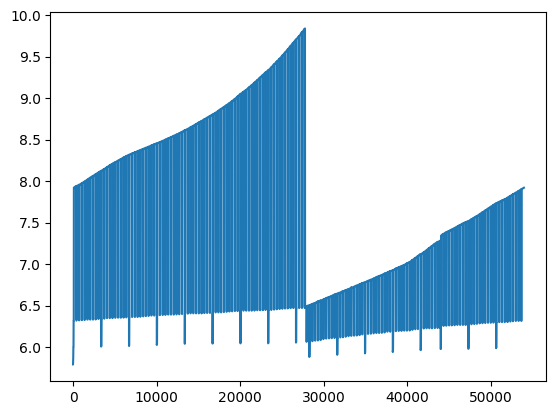

In [ ]:
#@title price 확인
Y.plot()

### 모델 생성 및 학습

In [ ]:
#@title 선형회귀모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))
print(model.summary())
model.compile(optimizer='adam', loss='mse')
#model.get_weights()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#@title 학습
%%time
history = model.fit(X, Y, epochs=1000, verbose=0)
model.get_weights()

CPU times: user 1h 11min 3s, sys: 5min 45s, total: 1h 16min 48s
Wall time: 59min 50s


In [ ]:
#@title 학습 - EarlyStopping
%%time
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(X, Y, epochs=10000, verbose=0, batch_size=128,
                    validation_split=0.2,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
                    )
#model.get_weights()

CPU times: user 1min 6s, sys: 6.09 s, total: 1min 12s
Wall time: 59.6 s


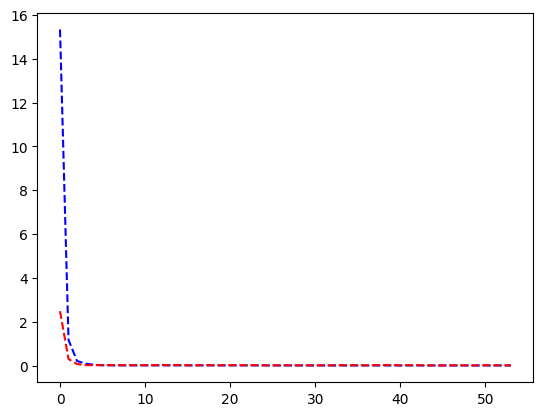

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], 'b--')
plt.plot(history.history['val_loss'], 'r--')
plt.show()

In [ ]:
model.save('diamonds1000.keras')
model.get_weights()

[array([[8761.71   ],
        [-150.26768],
        [-334.86224],
        [-500.04263]], dtype=float32),
 array([-4.9609003], dtype=float32)]

In [ ]:
model.evaluate(X, Y)

1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1644501.7500


1644501.75

In [ ]:
import tensorflow as tf

new_model = tf.keras.models.load_model('diamonds1000.keras')

print(new_model.summary())
new_model.get_weights()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (32.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

None


[array([[8761.71   ],
        [-150.26768],
        [-334.86224],
        [-500.04263]], dtype=float32),
 array([-4.9609003], dtype=float32)]

In [ ]:
import pandas as pd
import numpy as np
pred = new_model.predict(X)

df = pd.DataFrame({'price':Y, 'pred':np.reshape(pred, -1)})

NameError: name 'new_model' is not defined

1686/1686 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
      price      pred
0  5.789960  6.069257
1  5.789960  6.086539
2  5.793014  6.125927
3  5.814131  6.257747
4  5.817111  5.960185
5  5.820083  6.058333
6  5.820083  6.262439
7  5.823046  6.035727
8  5.823046  5.918031
9  5.826000  6.123800


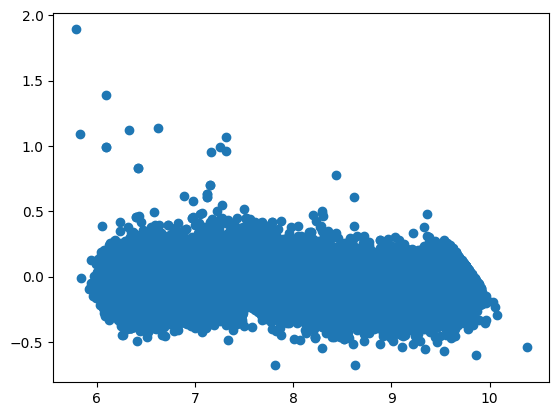

In [ ]:
#@title 잔차 그래프, 이산분산성(Heteroscedasticity)을 보임
import matplotlib.pyplot as plt
df = pd.DataFrame({'price':Y, 'pred':model.predict(X).flatten()})
print(df.head(10))
plt.scatter(df.pred, df.price-df.pred)

### 학습 속도 향상을 위한 데이터 축소


In [ ]:
#@title 데이터 로딩
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dm = sns.load_dataset('diamonds')
dm.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
#@title 이상치 확인, x, y, z는 0이 될 수 없음.
dm[(dm == 0).any(axis=1)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [ ]:
#@title 값이 0인 행 제외
dm = dm[~(dm == 0).any(axis=1)].reset_index().copy()
dm[(dm == 0).any(axis=1)]

,index,carat,cut,color,clarity,depth,table,price,x,y,z
0,0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43


In [ ]:
#@title N개의 임의의 행만 추출함.
N = 1000
dm_sample = dm.sample(n=N, random_state=42).reset_index()
dm_sample.describe()

,level_0,index,carat,depth,table,price,x,y,z
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27132.302000,27144.213000,0.811350,61.717800,57.447900,4045.033000,5.766810,5.795100,3.560190
std,15416.548986,15422.241598,0.480824,1.409372,2.412728,4058.224534,1.133306,1.394896,0.695644
min,80.000000,80.000000,0.210000,53.200000,50.000000,384.000000,3.890000,3.860000,2.290000
25%,13909.750000,13917.750000,0.400000,61.100000,56.000000,955.000000,4.730000,4.720000,2.930000
50%,26975.000000,26988.000000,0.710000,61.900000,57.000000,2452.500000,5.720000,5.735000,3.550000
75%,40319.250000,40336.250000,1.050000,62.500000,59.000000,5456.750000,6.570000,6.580000,4.040000
max,53876.000000,53896.000000,3.040000,68.800000,79.000000,18710.000000,9.510000,31.800000,5.620000


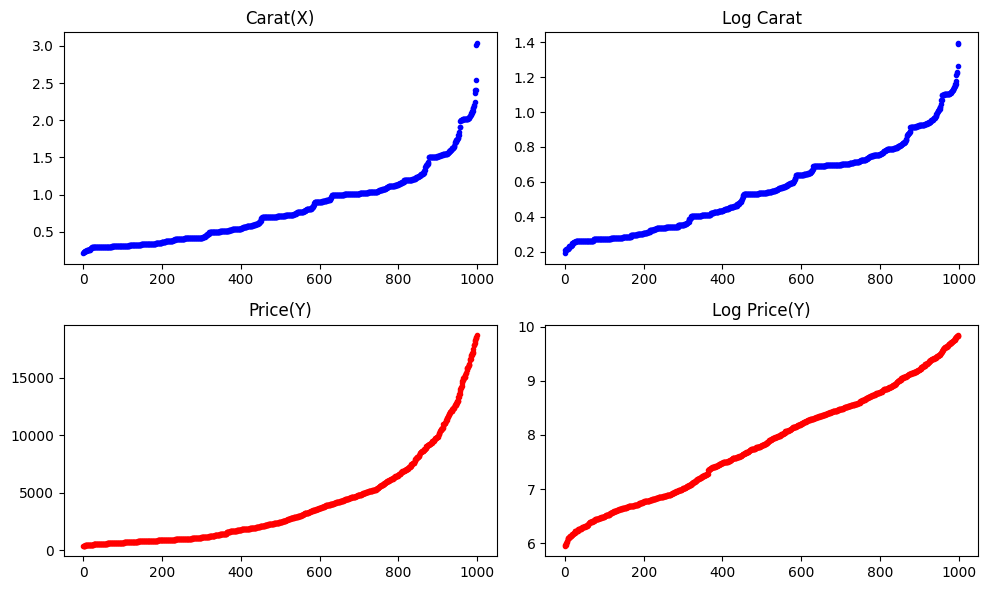

In [ ]:
#@title 차트로 확인
fig, axes = plt.subplots(2, 2, figsize=(10,6))

axes[0,0].plot(range(1000), dm_sample.sort_values('carat').carat, 'b.')
axes[0,0].set_title("Carat(X)")

axes[0,1].plot(range(1000), np.log1p(dm_sample.sort_values('carat').carat), 'b.')
axes[0,1].set_title("Log Carat")

axes[1,0].plot(range(1000), dm_sample.sort_values('price').price, 'r.')
axes[1,0].set_title("Price(Y)")

axes[1,1].plot(range(1000), np.log1p(dm_sample.sort_values('price').price), 'r.')
axes[1,1].set_title("Log Price(Y)")

plt.tight_layout()
plt.show()

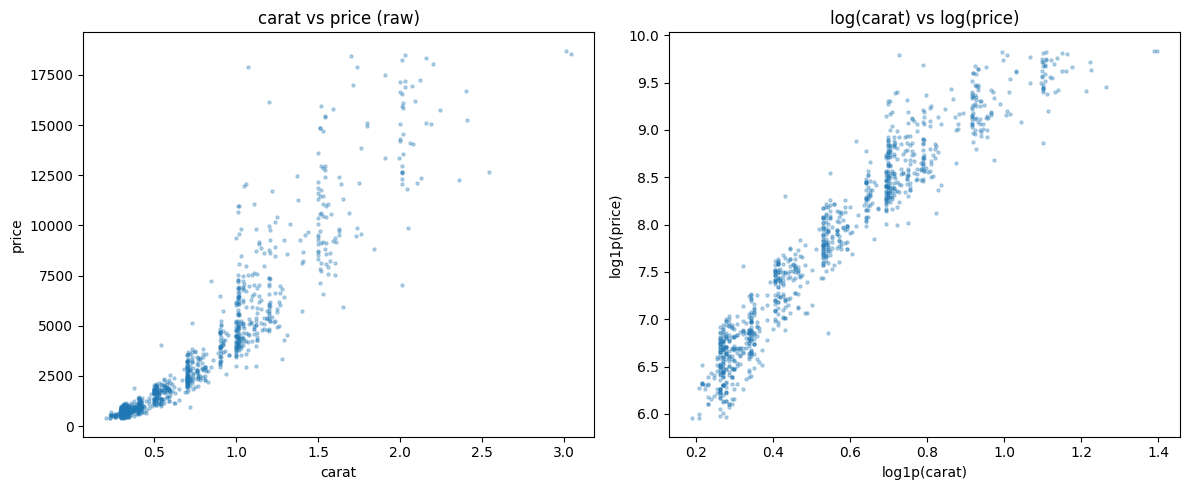

In [ ]:
#@title 원본 및 로그 차트 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(dm_sample.carat, dm_sample.price, s=5, alpha=0.3)
axes[0].set_xlabel("carat")
axes[0].set_ylabel("price")
axes[0].set_title("carat vs price (raw)")

axes[1].scatter(np.log1p(dm_sample.carat), np.log1p(dm_sample.price), s=5, alpha=0.3)
axes[1].set_xlabel("log1p(carat)")
axes[1].set_ylabel("log1p(price)")
axes[1].set_title("log(carat) vs log(price)")

plt.tight_layout()
plt.show()

In [ ]:
#@title 독립변수와 종속변수 할당
X = dm_sample.carat
Y = dm_sample.price
X, Y

(0      0.31
 1      1.29
 2      1.52
 3      0.41
 4      0.35
        ... 
 995    1.00
 996    2.19
 997    1.21
 998    1.03
 999    0.40
 Name: carat, Length: 1000, dtype: float64,
 0        874
 1       9273
 2      11743
 3       1064
 4        906
        ...  
 995     3763
 996    15032
 997     8616
 998     4441
 999     1404
 Name: price, Length: 1000, dtype: int64)

In [ ]:
#@title 선형회귀모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))
print(model.summary())
model.compile(optimizer='sgd', loss='mse')
model.get_weights()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

None


[array([[0.28257477]], dtype=float32), array([0.], dtype=float32)]

In [ ]:
#@title 원본 데이터로 훈련
%%time
history_raw = model.fit(X, Y, epochs=1000, verbose=0)
model.save('diamonds1000_raw.keras')
model.get_weights()

CPU times: user 1min 55s, sys: 16.3 s, total: 2min 11s
Wall time: 1min 56s


[array([[7862.4443]], dtype=float32), array([-2309.1714], dtype=float32)]

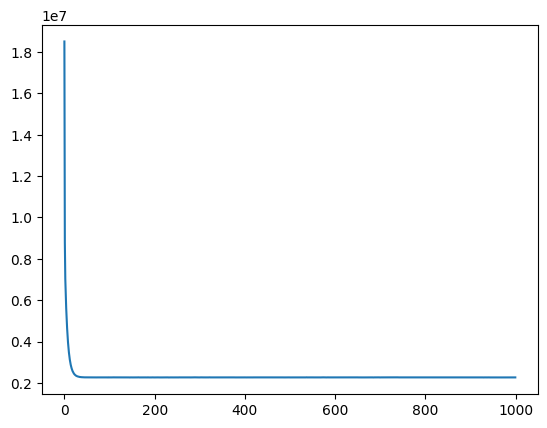

In [ ]:
plt.plot(history_raw.history['loss'])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


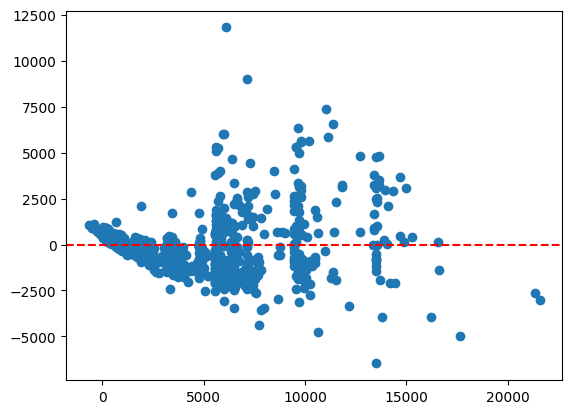

In [ ]:
#@title 잔차 그래프
pred_raw = pd.DataFrame({'price':Y, 'predict':model.predict(X).flatten()})
plt.scatter(pred_raw.predict, pred_raw.price-pred_raw.predict)
plt.axhline(0, color='red', linestyle='--')

In [ ]:
#@title 표준화 함수
def stdize(x):
  return (x-x.mean())/x.std()

In [ ]:
#@title 로그 데이터로 훈련
%%time
history_log = model.fit(stdize(np.log1p(X)), np.log1p(Y), epochs=1000, batch_size=32, verbose=0)
model.save('diamonds1000_log.keras')
model.get_weights()

CPU times: user 1min 55s, sys: 16.5 s, total: 2min 12s
Wall time: 1min 58s


[array([[0.9731248]], dtype=float32), array([7.8175683], dtype=float32)]

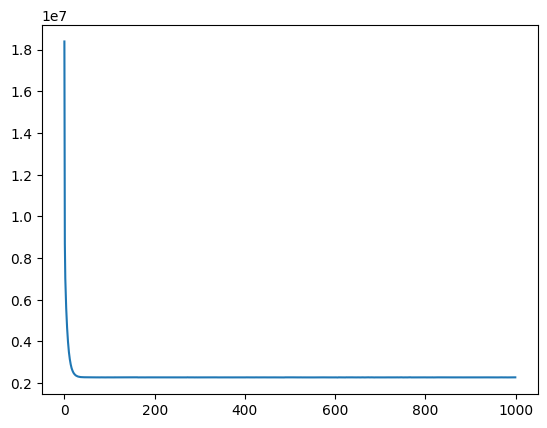

In [ ]:
plt.plot(history_raw.history['loss'])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


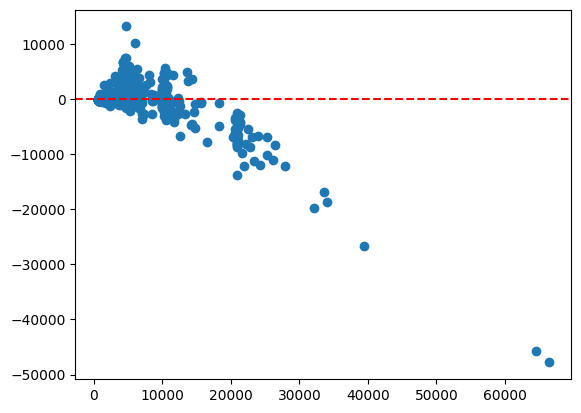

In [ ]:
#@title 잔차 그래프
pred_log = pd.DataFrame({
    'price': Y,
    'predict': np.expm1(model.predict(stdize(np.log1p(X))).flatten())  # log 역변환
})

plt.scatter(pred_log.predict, pred_log.price - pred_log.predict)  # pred_log로 통일
plt.axhline(0, color='red', linestyle='--')

#### 해결해야 할 문제들
- 문제점
  - 고가 구간 이분산성 여전히 존재	: price 12,000 이상에서 잔차 폭이 -50,000까지 벌어짐.  
  - 비대칭성: 양의 잔차(과대예측)보다 음의 잔차(과소예측)가 훨씬 크고 많음. 즉, 모델이 초고가 다이아몬드 가격을 체계적으로 과소평가하고 있다는 신호
  - 원인 후보 : 같은 carat이라도 clarity/color/cut이 좋아서 훨씬 비싼 다이아몬드들의 예측 오차가 큼.

- 결론
  - carat 단일변수 모델치고는	훌륭 : 변수 1개로 log 변환 효과를 보여준다.  
  - 최종 완성도로는	부족 : 음의 극단 잔차들이 cut/clarity/color를 넣어야 줄어들 패턴이라, 다변량 모델이 필요함